In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append('..')

from src.kitti_utils import load_kitti_calib
from src.geometry import estimate_vanishing_point
from src.visualization import plot_vanishing_point_validation

BASE_PATH = "D:/reyci/Politecnico di Milano/2025-2/Image Analysis and CV/Project/Code/IACV-Depth-Estimation-from-Temporal-Stereo-in-Monocular-Driving-Sequences-/data/raw/2011_09_26_drive_0001_extract"

IMG_PATH = os.path.join(BASE_PATH, "image_02/data")
CALIB_CAM_PATH = os.path.join(BASE_PATH, "calib/calib_cam_to_cam.txt")
CALIB_VELO_PATH = os.path.join(BASE_PATH, "calib/calib_velo_to_cam.txt")

# Load test frame and calibration data
idx = 50
img = cv2.imread(os.path.join(IMG_PATH, f"{idx:010d}.png"))

P_rect, _ = load_kitti_calib(CALIB_CAM_PATH, CALIB_VELO_PATH)

# The theoretical FOE is the camera's Principal Point
foe_theoretical = np.array([P_rect[0, 2], P_rect[1, 2]])

print(f"Loaded theoretical FOE: {foe_theoretical}")

Loaded theoretical FOE: [609.5593 172.854 ]


In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# 1. ROI adjustment: Raise the lower boundary to ignore nearby horizontal markings
h, w = edges.shape
mask = np.zeros_like(edges)

# Raise the lower limit to h*0.9 to ignore the asphalt directly in front of the bumper
roi_pts = np.array(
    [[(w * 0.1, h * 0.9), (w * 0.45, h * 0.55), (w * 0.55, h * 0.55), (w * 0.9, h * 0.9)]],
    dtype=np.int32
)
cv2.fillPoly(mask, roi_pts, 255)
masked_edges = cv2.bitwise_and(edges, mask)

# 2. Hough transform with stricter length requirements
# to capture real longitudinal lines
lines = cv2.HoughLinesP(
    masked_edges,
    1,
    np.pi / 180,
    threshold=40,
    minLineLength=100,  # Longer lines are geometrically more stable
    maxLineGap=20
)

filtered_lines = []

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]

        # Compute angle for a more intuitive filter than slope
        angle = np.abs(np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi)

        # Strict filter: only accept lines clearly oriented toward the horizon
        # This definitively removes the horizontal markings seen in image_8f527e.jpg
        if 30 < angle < 85:
            filtered_lines.append(line)

# 3. Recompute the VP using the least-squares function from geometry.py
vp_estimated = estimate_vanishing_point(filtered_lines)

print(f"New estimated VP (filtered): {vp_estimated}")

New estimated VP (filtered): [712.05015353 225.08700102]


--- GEOMETRY DIAGNOSTICS ---
FOE-VP Distance: 115.03 pixels
STATUS: WARNING (115.0px). Possible curve/inclination.


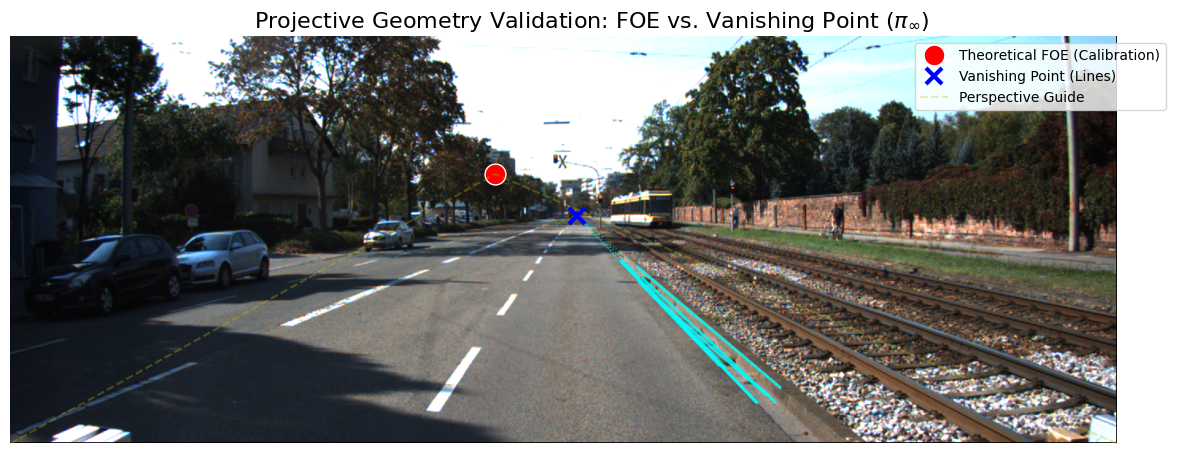

In [3]:
plot_vanishing_point_validation(
    img=img,
    foe_theoretical=foe_theoretical,
    vp_estimated=vp_estimated,
    filtered_lines=filtered_lines,
    title="Projective Geometry Validation: FOE vs. Vanishing Point ($\pi_\infty$)"
)